# A Hands-On Introduction to Hidden Markov Models (HMMs)

This notebook is a guided tour of **Hidden Markov Models**, blending two classic references:

- Mark Stamp, *A Revealing Introduction to Hidden Markov Models* (2021).
- Daniel Jurafsky & James H. Martin, *Speech and Language Processing*, Appendix A (2023).

It is **self-contained** and runs in Google Colab without any setup beyond `pip install`.

---

## 📚 Table of contents

1. **What is an HMM, and why should I care?**
2. **Markov chains** — the foundation.
3. **The Hidden Markov Model** — adding observations on top of hidden states.
4. **The three fundamental problems** of HMMs.
5. **Problem 1 — Likelihood:** the *Forward algorithm* (and *Backward* as a bonus).
6. **Problem 2 — Decoding:** the *Viterbi algorithm*.
7. **Problem 3 — Learning:** the *Baum–Welch* (Forward–Backward) algorithm.
8. **Numerical stability:** scaling to avoid underflow.
9. **Comparison with `hmmlearn`** — a battle-tested Python library.
10. **A larger experiment** — discovering vowels vs. consonants from raw text.
11. **Summary & further reading.**

Each section pairs a **plain-language explanation**, the **formal equations**, a **from-scratch implementation**, and a **visualization** so you can see what's happening.


## 1. What is an HMM, and why should I care?

Imagine you are a climatologist in the year 2799 trying to reconstruct what the weather was like in Baltimore during the summer of 2020. The weather records have been lost, but you find Jason Eisner's diary, which records **how many ice creams he ate each day**. The weather (the *state*) is hidden, but it influences something you *can* see (the *observation*).

This is exactly the situation an **HMM** is built for:

> An HMM models a **sequence of observations** that is generated by an **underlying sequence of hidden states**, where the states evolve according to a Markov process.

You'll meet HMMs in:

- **Speech recognition** — phonemes (hidden) generate audio frames (observed).
- **Part-of-speech tagging** — POS tags (hidden) generate words (observed).
- **Bioinformatics** — gene regions (hidden) generate DNA bases (observed).
- **Finance** — market regimes (hidden) generate returns (observed).

Throughout this notebook we use two small running examples:

- **Stamp's temperature/tree-rings example** — hidden weather (Hot/Cold) → tree-ring sizes (Small/Medium/Large).
- **Jurafsky's ice-cream example** — hidden weather (Hot/Cold) → ice-creams eaten (1/2/3).


### Setup

Run this cell first. We install everything we need, then import standard libraries.

In [1]:
# Install hmmlearn (used in section 9). Colab already has numpy/matplotlib/networkx.
# The `--quiet` flag keeps the output clean.
!pip install hmmlearn --quiet

# ---- Standard scientific Python stack ----
import numpy as np                      # numerical arrays / linear algebra
import matplotlib.pyplot as plt         # plotting
import matplotlib.patches as mpatches   # legend handles
import networkx as nx                   # drawing state-transition graphs

# Reproducibility: fix the random seed so every run gives identical results.
np.random.seed(42)

# A small numerical helper used in many places: compute log-sum-exp safely.
# (We won't always need it, but it's good practice.)
from scipy.special import logsumexp

# Pretty-print numpy arrays with 4 decimal places.
np.set_printoptions(precision=4, suppress=True)

print("Setup complete ✔")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 11.7 MB/s eta 0:00:00
Setup complete ✔


## 2. Markov chains — the foundation

Before we hide anything, let's understand the *visible* version: a **Markov chain**.

A Markov chain is a model of a sequence of random states $q_1, q_2, q_3, \dots$ that satisfies the **Markov assumption**:

$$
\boxed{\;P(q_i \mid q_1, q_2, \dots, q_{i-1}) \;=\; P(q_i \mid q_{i-1})\;}
$$

In words: **to predict the next state, only the current state matters** — the further past is irrelevant *given* the present.

A Markov chain is fully described by:

| Symbol | Meaning |
|---|---|
| $Q = \{q_0, q_1, \dots, q_{N-1}\}$ | the $N$ possible states |
| $A \in \mathbb{R}^{N\times N}$, with $a_{ij} = P(q_j \text{ at } t{+}1 \mid q_i \text{ at } t)$ | transition matrix (rows sum to 1) |
| $\pi \in \mathbb{R}^{N}$, with $\pi_i = P(q_0 = i)$ | initial state distribution (sums to 1) |

A matrix in which every row is a probability distribution (non-negative and sums to 1) is called **row-stochastic**.

### Stamp's weather example

- Two states: $H$ (hot) and $C$ (cold).
- Transition probabilities:
  - $P(H \to H) = 0.7$, $P(H \to C) = 0.3$
  - $P(C \to H) = 0.4$, $P(C \to C) = 0.6$
- Initial distribution: $\pi = [0.6,\, 0.4]$.


In [2]:
# ----------------------------------------------------------------
# Define Stamp's weather Markov chain
# ----------------------------------------------------------------
# State indices: 0 = Hot (H), 1 = Cold (C)
states = ["H", "C"]

# Transition matrix A: rows = current state, columns = next state
#   row 0 (from H): P(H->H)=0.7, P(H->C)=0.3
#   row 1 (from C): P(C->H)=0.4, P(C->C)=0.6
A = np.array([
    [0.7, 0.3],
    [0.4, 0.6],
])

# Initial state distribution pi
pi = np.array([0.6, 0.4])

# Quick sanity check: every row of A should sum to 1, and pi should sum to 1.
assert np.allclose(A.sum(axis=1), 1.0), "Rows of A must sum to 1"
assert np.isclose(pi.sum(), 1.0),       "pi must sum to 1"
print("Transition matrix A:\n", A)
print("Initial distribution pi:", pi)


Transition matrix A:
 [[0.7 0.3]
 [0.4 0.6]]
Initial distribution pi: [0.6 0.4]


### Simulating the chain

Once we have $\pi$ and $A$, we can **draw samples** of state sequences. We:

1. Sample the first state from $\pi$.
2. At every subsequent step $t$, sample $q_{t+1}$ from row $q_t$ of $A$.


In [3]:
def simulate_markov_chain(pi, A, T, rng=None):
    '''
    Generate a single sample state sequence of length T from a Markov chain.

    Parameters
    ----------
    pi  : (N,) initial state distribution.
    A   : (N, N) transition matrix (row-stochastic).
    T   : length of the sequence to generate.
    rng : optional np.random.Generator for reproducibility.

    Returns
    -------
    seq : list of int, length T, holding the sampled state indices.
    '''
    if rng is None:
        rng = np.random.default_rng()

    N = len(pi)
    seq = [rng.choice(N, p=pi)]              # first state from pi
    for _ in range(T - 1):
        # next state is drawn from row A[current_state]
        seq.append(rng.choice(N, p=A[seq[-1]]))
    return seq


# Generate a 20-day weather sequence and print it as H/C letters.
rng = np.random.default_rng(0)
sample = simulate_markov_chain(pi, A, T=20, rng=rng)
print("Sampled weather:", "".join(states[s] for s in sample))


Sampled weather: CHHHCCCCCCCHCHCHCCHH


### Visualizing the chain as a graph

Drawing the states as nodes and the transitions as labelled arrows makes the structure intuitive.

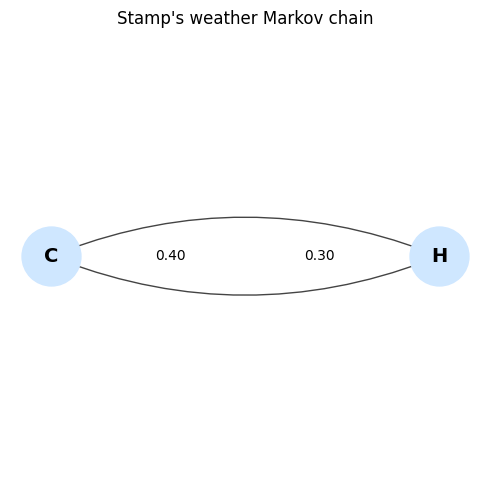

In [4]:
def draw_markov_chain(A, state_names, title="Markov chain"):
    '''
    Draw a state-transition diagram of a Markov chain.

    Each node is a state; each edge is labelled with its transition probability.
    Self-loops (q -> q) are drawn as well.
    '''
    G = nx.MultiDiGraph()
    N = len(state_names)
    for s in state_names:
        G.add_node(s)
    # Add an edge for every entry of A whose probability > 0
    for i in range(N):
        for j in range(N):
            if A[i, j] > 0:
                G.add_edge(state_names[i], state_names[j], weight=A[i, j])

    pos = nx.circular_layout(G)
    fig, ax = plt.subplots(figsize=(5, 5))
    nx.draw_networkx_nodes(G, pos, node_size=1800, node_color="#cfe7ff", ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=14, font_weight="bold", ax=ax)

    # Curve the arrows so two-way transitions don't overlap
    nx.draw_networkx_edges(
        G, pos, connectionstyle="arc3,rad=0.2",
        arrowsize=20, edge_color="#444", ax=ax,
    )
    # Build a label dict {(u, v): "0.70"} for the edges
    edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, label_pos=0.3, font_size=10, ax=ax
    )
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


draw_markov_chain(A, states, title="Stamp's weather Markov chain")


## 3. The Hidden Markov Model

A plain Markov chain only describes the *state* sequence — but in many real problems we **don't observe the states directly**. Instead, each state stochastically emits an **observation symbol**.

An HMM extends a Markov chain with one extra ingredient:

- An **observation alphabet** $V = \{0, 1, \dots, M-1\}$.
- An **emission matrix** $B \in \mathbb{R}^{N\times M}$, where
  $$b_j(k) = P(\text{observation } k \text{ at time } t \mid \text{state } q_j \text{ at time } t).$$

So an HMM is the triple
$$\boxed{\;\lambda = (A,\, B,\, \pi)\;}$$
together with the implicit dimensions $N$ (number of states) and $M$ (size of the observation alphabet).

The two **assumptions** are:

1. **Markov assumption (states):** $\;P(q_t \mid q_1,\dots,q_{t-1}) = P(q_t \mid q_{t-1})$.
2. **Output independence (emissions):** $\;P(o_t \mid q_1,\dots,q_T,\, o_1,\dots,o_T) = P(o_t \mid q_t)$.

### Stamp's full HMM

- Hidden states: $H$ (hot), $C$ (cold).
- Observations: tree-ring sizes — $0$ = Small, $1$ = Medium, $2$ = Large.
- Emission matrix:

$$
B \;=\; \begin{array}{c|ccc} & S & M & L \\ \hline H & 0.1 & 0.4 & 0.5 \\ C & 0.7 & 0.2 & 0.1 \end{array}
$$

Hot years tend to grow large rings; cold years tend to grow small rings.


In [5]:
# ----------------------------------------------------------------
# Define the full HMM lambda = (A, B, pi)
# ----------------------------------------------------------------
# A and pi were defined earlier. Now we add the emission matrix B.

# Observation alphabet (just for printing): 0 -> S, 1 -> M, 2 -> L
obs_symbols = ["S", "M", "L"]

# Emission matrix B: row = state, column = observation symbol
B = np.array([
    [0.1, 0.4, 0.5],   # state H emits (S, M, L) with these probs
    [0.7, 0.2, 0.1],   # state C emits (S, M, L) with these probs
])

# Sanity checks
assert np.allclose(B.sum(axis=1), 1.0), "Rows of B must sum to 1"

print(f"Number of hidden states  N = {A.shape[0]}")
print(f"Number of observations   M = {B.shape[1]}")
print("\nA =\n", A)
print("\nB =\n", B)
print("\npi =", pi)


Number of hidden states  N = 2
Number of observations   M = 3

A =
 [[0.7 0.3]
 [0.4 0.6]]

B =
 [[0.1 0.4 0.5]
 [0.7 0.2 0.1]]

pi = [0.6 0.4]


### Sampling an observation sequence from an HMM

To generate data from an HMM we alternate two steps:

1. **Transition:** draw the next hidden state from $A$ (or from $\pi$ at $t=0$).
2. **Emission:** draw the observation from row $B[q_t]$.

In [6]:
def simulate_hmm(pi, A, B, T, rng=None):
    '''
    Sample one (state-sequence, observation-sequence) pair of length T from an HMM.

    Returns
    -------
    states : np.ndarray of shape (T,) with hidden state indices.
    obs    : np.ndarray of shape (T,) with observation indices.
    '''
    if rng is None:
        rng = np.random.default_rng()

    N, M = B.shape
    states = np.empty(T, dtype=int)
    obs    = np.empty(T, dtype=int)

    # t = 0: pick initial state from pi, then emit
    states[0] = rng.choice(N, p=pi)
    obs[0]    = rng.choice(M, p=B[states[0]])

    # t >= 1: transition then emit
    for t in range(1, T):
        states[t] = rng.choice(N, p=A[states[t - 1]])
        obs[t]    = rng.choice(M, p=B[states[t]])

    return states, obs


# Generate a 12-step sample
rng = np.random.default_rng(7)
true_states, observations = simulate_hmm(pi, A, B, T=12, rng=rng)

print("Hidden states :", "".join(states[s]      for s in true_states))
print("Observations  :", "".join(obs_symbols[o] for o in observations))


Hidden states : CCHHCHHHCCHH
Observations  : MSLLSMMLMLMS


## 4. The three fundamental problems

Following Rabiner's classic 1989 tutorial, three questions cover essentially everything you'd ever want to do with an HMM:

| # | Name | Given | Find |
|---|------|-------|------|
| 1 | **Likelihood (Evaluation)** | model $\lambda$ and observation sequence $O$ | $P(O \mid \lambda)$ — how well does the model explain the data? |
| 2 | **Decoding**   | model $\lambda$ and observation sequence $O$ | the most likely hidden state sequence $X^*$ |
| 3 | **Learning**   | observation sequence $O$ and dimensions $N, M$ | the parameters $\lambda = (A, B, \pi)$ that maximise $P(O \mid \lambda)$ |

The next three sections solve them in order.


## 5. Problem 1 — Likelihood: the Forward algorithm

We want $P(O \mid \lambda)$ for an observation sequence $O = (O_0, O_1, \dots, O_{T-1})$.

### The naïve view (don't actually do this)

We could sum over **every possible** hidden state sequence $X = (x_0, \dots, x_{T-1})$:

$$
P(O \mid \lambda) \;=\; \sum_{X} P(O, X \mid \lambda)
\;=\; \sum_{X} \pi_{x_0}\, b_{x_0}(O_0)\, a_{x_0,x_1}\, b_{x_1}(O_1)\, \cdots\, a_{x_{T-2},x_{T-1}}\, b_{x_{T-1}}(O_{T-1}).
$$

There are $N^T$ such sequences — for $N=5,\, T=100$ that's $\sim 10^{70}$ terms. Forget it.

### The clever view: the **Forward** recursion

Define the **forward variable**
$$
\alpha_t(i) \;=\; P(O_0, O_1, \dots, O_t,\; x_t = q_i \mid \lambda),
$$
the joint probability of the observations *up to* time $t$ and being in state $i$ at time $t$.

Then $\alpha$ obeys a simple recurrence:

$$
\begin{aligned}
\text{Init:}\qquad & \alpha_0(i) = \pi_i\, b_i(O_0) \\
\text{Recurse:}\qquad & \alpha_t(i) = \Bigl[\sum_{j=0}^{N-1} \alpha_{t-1}(j)\, a_{ji}\Bigr]\, b_i(O_t) \\
\text{Terminate:}\qquad & P(O \mid \lambda) = \sum_{i=0}^{N-1} \alpha_{T-1}(i)
\end{aligned}
$$

This is **dynamic programming**: each cell of the trellis is reused. Cost: $O(N^2 T)$ multiplications instead of $O(N^T)$.


In [7]:
def forward(pi, A, B, O):
    '''
    Forward algorithm (no scaling — fine for short sequences).

    Parameters
    ----------
    pi : (N,) initial state distribution.
    A  : (N, N) transition matrix.
    B  : (N, M) emission matrix.
    O  : (T,) observation sequence as integer indices into B's columns.

    Returns
    -------
    alpha : (T, N) forward probabilities.
    pO    : float, the total likelihood P(O | lambda) = sum_i alpha[T-1, i].
    '''
    T = len(O)
    N = A.shape[0]
    alpha = np.zeros((T, N))

    # ---- t = 0: initialise with pi * B[:, O[0]] ----
    alpha[0] = pi * B[:, O[0]]

    # ---- t = 1, 2, ..., T-1: propagate forward ----
    for t in range(1, T):
        # alpha[t-1] @ A gives, for each next-state j, sum_i alpha[t-1, i] * A[i, j].
        # We then multiply elementwise by B[:, O[t]] (the emission probability for O[t]).
        alpha[t] = (alpha[t - 1] @ A) * B[:, O[t]]

    pO = alpha[-1].sum()
    return alpha, pO


# Stamp's worked example: O = (S, M, S, L) = (0, 1, 0, 2)
O_demo = np.array([0, 1, 0, 2])
alpha, pO = forward(pi, A, B, O_demo)

print("Observation sequence:", [obs_symbols[o] for o in O_demo])
print("\nForward variables alpha[t, i] (rows = t, columns = state):")
print(alpha)
print(f"\nP(O | lambda) = {pO:.6f}")


Observation sequence: ['S', 'M', 'S', 'L']

Forward variables alpha[t, i] (rows = t, columns = state):
[[0.06   0.28  ]
 [0.0616 0.0372]
 [0.0058 0.0286]
 [0.0077 0.0019]]

P(O | lambda) = 0.009630


### Sanity check against brute force

For a short sequence we can also compute the likelihood by summing over **all** $N^T$ state sequences and verify the forward algorithm gives the same number.

In [8]:
from itertools import product

def brute_force_likelihood(pi, A, B, O):
    '''
    Compute P(O | lambda) by enumerating ALL N**T hidden sequences.
    Only feasible for tiny T; provided for verification.
    '''
    T = len(O)
    N = A.shape[0]
    total = 0.0
    # product([0,...,N-1], repeat=T) iterates over every state sequence
    for X in product(range(N), repeat=T):
        # P(O, X | lambda) = pi_x0 * b_x0(O0) * a_x0x1 * b_x1(O1) * ...
        p = pi[X[0]] * B[X[0], O[0]]
        for t in range(1, T):
            p *= A[X[t - 1], X[t]] * B[X[t], O[t]]
        total += p
    return total

p_brute = brute_force_likelihood(pi, A, B, O_demo)
print(f"Forward     P(O|lambda) = {pO:.8f}")
print(f"Brute force P(O|lambda) = {p_brute:.8f}")
print("Match!" if np.isclose(pO, p_brute) else "MISMATCH")


Forward     P(O|lambda) = 0.00962960
Brute force P(O|lambda) = 0.00962960
Match!


### Visualizing the forward trellis

A trellis plot makes the recursion very tangible: each column is a time step, each row a state, and each cell contains $\alpha_t(i)$.

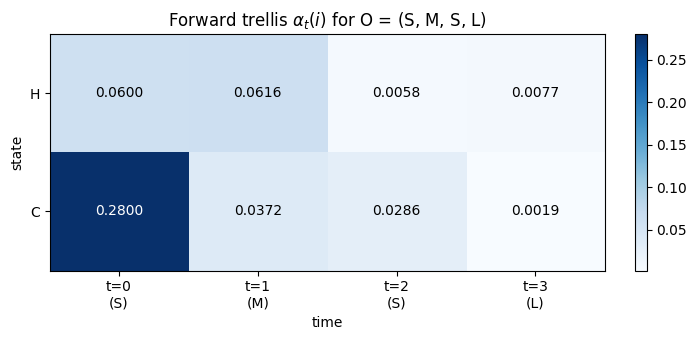

In [9]:
def plot_trellis(values, state_names, obs_names, title, fmt="{:.4f}"):
    '''
    Plot a (T, N) DP table as a labelled grid (the 'trellis').

    `values` is the matrix to display, `state_names` label the rows
    and `obs_names` (one per column) label the time axis.
    '''
    T, N = values.shape
    fig, ax = plt.subplots(figsize=(1.4 * T + 1.5, 1.0 * N + 1.5))

    # imshow the matrix transposed so rows = states, cols = time
    im = ax.imshow(values.T, cmap="Blues", aspect="auto")
    ax.set_xticks(range(T))
    ax.set_xticklabels([f"t={t}\n({obs_names[t]})" for t in range(T)])
    ax.set_yticks(range(N))
    ax.set_yticklabels(state_names)
    ax.set_xlabel("time")
    ax.set_ylabel("state")
    ax.set_title(title)

    # Annotate each cell with its numeric value
    for t in range(T):
        for i in range(N):
            ax.text(t, i, fmt.format(values[t, i]),
                    ha="center", va="center", fontsize=10,
                    color="black" if values[t, i] < values.max() * 0.6 else "white")

    fig.colorbar(im, ax=ax, fraction=0.025)
    plt.tight_layout()
    plt.show()


plot_trellis(alpha, states, [obs_symbols[o] for o in O_demo],
             title=r"Forward trellis $\alpha_t(i)$ for O = (S, M, S, L)")


### The Backward algorithm (we'll need it for learning)

The mirror image of $\alpha$ is the **backward variable**:
$$
\beta_t(i) \;=\; P(O_{t+1}, O_{t+2}, \dots, O_{T-1} \mid x_t = q_i,\, \lambda).
$$
That is, $\beta_t(i)$ is the probability of the *future* observations given that we are in state $i$ at time $t$.

$$
\begin{aligned}
\text{Init:}\qquad     & \beta_{T-1}(i) = 1 \\
\text{Recurse:}\qquad  & \beta_t(i) = \sum_{j=0}^{N-1} a_{ij}\, b_j(O_{t+1})\, \beta_{t+1}(j),\quad t = T-2, \dots, 0
\end{aligned}
$$

We won't strictly need $\beta$ for evaluation, but it is essential for the **Baum–Welch** parameter estimation in section 7.


In [10]:
def backward(A, B, O):
    '''
    Backward algorithm (no scaling).

    Returns
    -------
    beta : (T, N) backward probabilities, where beta[t, i] = P(O_{t+1..T-1} | x_t=i).
    '''
    T = len(O)
    N = A.shape[0]
    beta = np.zeros((T, N))

    # ---- Initialisation: beta_{T-1}(i) = 1 for all i ----
    beta[-1] = 1.0

    # ---- Recursion: walk backwards from T-2 to 0 ----
    for t in range(T - 2, -1, -1):
        # For each state i, sum_j A[i, j] * B[j, O[t+1]] * beta[t+1, j]
        beta[t] = A @ (B[:, O[t + 1]] * beta[t + 1])

    return beta


beta = backward(A, B, O_demo)
print("Backward variables beta[t, i]:")
print(beta)

# Cross-check: P(O | lambda) can also be computed using alpha and beta together.
# At any time t,  P(O|lambda) = sum_i alpha[t, i] * beta[t, i].
p_alpha_beta = (alpha[0] * beta[0]).sum()
print(f"\nP(O|lambda) via forward only        = {pO:.6f}")
print(f"P(O|lambda) via alpha*beta at t = 0 = {p_alpha_beta:.6f}")


Backward variables beta[t, i]:
[[0.0302 0.0279]
 [0.0812 0.1244]
 [0.38   0.26  ]
 [1.     1.    ]]

P(O|lambda) via forward only        = 0.009630
P(O|lambda) via alpha*beta at t = 0 = 0.009630


## 6. Problem 2 — Decoding: the Viterbi algorithm

Now we want the **most likely hidden state sequence** that explains the observations:
$$
X^{*} \;=\; \arg\max_{X}\; P(X \mid O, \lambda) \;=\; \arg\max_{X}\; P(X, O \mid \lambda).
$$

The trick is the same as for the forward algorithm — but we replace **sum** with **max**, and we keep **back-pointers** so we can reconstruct the winning path.

Define
$$
v_t(j) \;=\; \max_{x_0, \dots, x_{t-1}}\; P(x_0, \dots, x_{t-1}, O_0, \dots, O_t,\; x_t = q_j \mid \lambda).
$$

Then:

$$
\begin{aligned}
\text{Init:}\qquad     & v_0(j) = \pi_j\, b_j(O_0) \\
\text{Recurse:}\qquad  & v_t(j) = \max_{i}\; v_{t-1}(i)\, a_{ij}\, b_j(O_t) \\
                       & \text{bp}_t(j) = \arg\max_{i}\; v_{t-1}(i)\, a_{ij}\, b_j(O_t) \\
\text{Terminate:}\qquad& P^{*} = \max_{i} v_{T-1}(i),\quad x^{*}_{T-1} = \arg\max_{i} v_{T-1}(i)
\end{aligned}
$$

Then **back-trace** through the $\text{bp}$ pointers to recover $X^*$.

### Numerical note: work in log-space

Because we're chaining many small probabilities together, $v_t(j)$ shrinks exponentially. The standard fix is to take logs:
$$
\hat v_t(j) \;=\; \max_i \bigl[\hat v_{t-1}(i) + \log a_{ij}\bigr] + \log b_j(O_t).
$$
Sums of logs are numerically safe.


In [11]:
def viterbi(pi, A, B, O):
    '''
    Viterbi decoding in log-space (avoids underflow on long sequences).

    Returns
    -------
    best_path : np.ndarray of shape (T,) — the most likely hidden state sequence.
    best_logp : float — log P(X*, O | lambda) for that path.
    log_v     : (T, N) — log-Viterbi variables (useful for plotting).
    '''
    T = len(O)
    N = A.shape[0]

    # We add a tiny epsilon to avoid log(0). Log(0) -> -inf can cause warnings
    # but is mathematically fine; the eps just tidies up corner cases.
    EPS = 1e-300
    log_pi = np.log(pi + EPS)
    log_A  = np.log(A  + EPS)
    log_B  = np.log(B  + EPS)

    log_v   = np.full((T, N), -np.inf)   # log Viterbi values
    bp      = np.zeros((T, N), dtype=int)  # back-pointers

    # ---- Initialisation ----
    log_v[0] = log_pi + log_B[:, O[0]]
    # bp[0] is unused — there's no previous step

    # ---- Recursion ----
    for t in range(1, T):
        # For each next-state j, we need max over previous state i of:
        #       log_v[t-1, i] + log_A[i, j]
        # `scores[i, j]` below is exactly that quantity.
        scores = log_v[t - 1, :, None] + log_A   # shape (N, N)
        bp[t]    = np.argmax(scores, axis=0)     # which i maximised
        log_v[t] = np.max(scores,    axis=0) + log_B[:, O[t]]

    # ---- Termination + back-trace ----
    best_logp = log_v[-1].max()
    best_path = np.empty(T, dtype=int)
    best_path[-1] = log_v[-1].argmax()
    for t in range(T - 2, -1, -1):
        best_path[t] = bp[t + 1, best_path[t + 1]]

    return best_path, best_logp, log_v


# Decode Stamp's example O = (S, M, S, L)
best_path, best_logp, log_v = viterbi(pi, A, B, O_demo)
print(f"Observations            : {[obs_symbols[o] for o in O_demo]}")
print(f"Most likely state seq   : {[states[s] for s in best_path]}")
print(f"log P(X*, O | lambda)   : {best_logp:.4f}")
print(f"P(X*, O | lambda)       : {np.exp(best_logp):.6f}")


Observations            : ['S', 'M', 'S', 'L']
Most likely state seq   : ['C', 'C', 'C', 'H']
log P(X*, O | lambda)   : -5.8702
P(X*, O | lambda)       : 0.002822


**Comparing the two notions of "most likely"**

There are two reasonable definitions of the *best* state sequence:

- **DP / Viterbi:** the *single* sequence with highest joint probability $P(X, O \mid \lambda)$.
- **Posterior / HMM-sense:** at each time $t$, pick the state with highest *marginal* posterior $\gamma_t(i) = P(x_t = i \mid O, \lambda)$.

These two answers can disagree (Stamp gives an explicit example: the Viterbi path is `CCCH` but the marginal-best path is `CHCH`). We'll compute $\gamma$ in the next section — it's exactly what Baum–Welch needs.


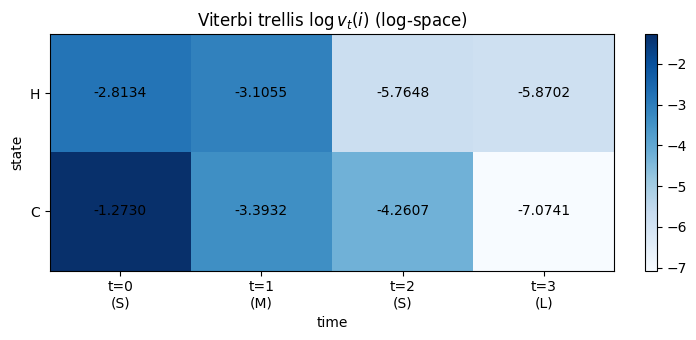

In [12]:
# Visualise the log-Viterbi trellis
plot_trellis(log_v, states, [obs_symbols[o] for o in O_demo],
             title=r"Viterbi trellis $\log v_t(i)$ (log-space)")


## 7. Problem 3 — Learning: the Baum–Welch (Forward–Backward) algorithm

Now we tackle the hard case: **we have observations $O$, we know how many states $N$ to use, but we don't know $A$, $B$, or $\pi$.** Can we estimate them?

If we *did* know the true hidden state at every $t$, this would be trivial — we'd just count transitions and emissions and normalise. But we don't. **Baum–Welch** is the EM (expectation-maximisation) recipe for this:

> Iteratively **guess soft state assignments** ($\gamma$ and $\xi$) using the current parameters, then **re-estimate** parameters as if those soft assignments were true.

### Two new quantities

The **state-occupancy** (gamma):
$$
\gamma_t(i) \;=\; P(x_t = q_i \mid O, \lambda) \;=\; \frac{\alpha_t(i)\,\beta_t(i)}{P(O \mid \lambda)}.
$$

The **state-pair / transition** (xi, sometimes called the "di-gamma"):
$$
\xi_t(i, j) \;=\; P(x_t = q_i,\, x_{t+1} = q_j \mid O, \lambda) \;=\; \frac{\alpha_t(i)\, a_{ij}\, b_j(O_{t+1})\, \beta_{t+1}(j)}{P(O \mid \lambda)}.
$$

Note that $\gamma_t(i) = \sum_j \xi_t(i, j)$ — they are consistent.

### Re-estimation formulas (the M-step)

$$
\begin{aligned}
\hat\pi_i      &= \gamma_0(i) \\[4pt]
\hat a_{ij}    &= \dfrac{\sum_{t=0}^{T-2} \xi_t(i, j)}{\sum_{t=0}^{T-2} \gamma_t(i)}
                  \quad \text{(expected }i\!\to\!j\text{ transitions)} \big/ \text{(expected times in }i\text{)} \\[8pt]
\hat b_j(k)    &= \dfrac{\sum_{t:\, O_t = k}\, \gamma_t(j)}{\sum_{t=0}^{T-1} \gamma_t(j)}
                  \quad \text{(expected times in }j\text{ emitting }k\text{)} \big/ \text{(expected times in }j\text{)}
\end{aligned}
$$

### The full loop

1. **Initialise** $A$, $B$, $\pi$ randomly (but *not* uniformly — uniform values are a stationary point of EM!).
2. **E-step:** run forward and backward passes, compute $\gamma_t(i)$ and $\xi_t(i, j)$.
3. **M-step:** apply the re-estimation formulas above.
4. Compute $\log P(O \mid \lambda)$.
5. If it has improved by more than a small threshold (and we're under the iteration cap), go to 2.

It's guaranteed that $P(O\mid\lambda)$ never decreases — but EM can get stuck in local maxima, so different random starts can give different solutions.


### Why scaling is essential

Both $\alpha_t(i)$ and $\beta_t(i)$ shrink toward $0$ exponentially fast in $T$. Without re-scaling they'll underflow to $0$ on any sequence longer than a few dozen steps and the re-estimation formulas break.

The standard fix (Stamp, §6) is:

- After computing $\alpha_t$, divide it by $c_t = 1 / \sum_i \alpha_t(i)$ so that $\sum_i \hat\alpha_t(i) = 1$.
- Use the **same** scale factors $c_t$ on $\beta_t$.
- The likelihood is then recovered as $\log P(O \mid \lambda) = -\sum_t \log c_t$.

Crucially, **the $\xi$ and $\gamma$ formulas come out exactly the same** because the scale factors cancel in the ratio. The implementation below uses scaling.


In [13]:
def forward_scaled(pi, A, B, O):
    '''
    Scaled forward algorithm. Returns alpha_hat (shape T x N) and the
    scale factors c (shape T,). Crucially, sum_i alpha_hat[t, i] = 1 for every t,
    and  log P(O | lambda) = -sum_t log c[t].
    '''
    T = len(O)
    N = A.shape[0]
    alpha = np.zeros((T, N))
    c     = np.zeros(T)

    # ---- t = 0 ----
    alpha[0] = pi * B[:, O[0]]
    c[0]     = 1.0 / alpha[0].sum()
    alpha[0] *= c[0]                     # rescale so it sums to 1

    # ---- t = 1, ..., T-1 ----
    for t in range(1, T):
        alpha[t] = (alpha[t - 1] @ A) * B[:, O[t]]
        c[t]     = 1.0 / alpha[t].sum()
        alpha[t] *= c[t]

    return alpha, c


def backward_scaled(A, B, O, c):
    '''
    Scaled backward algorithm. Uses the SAME scale factors c[t] computed
    by forward_scaled — that's what makes the E-step formulas exact.
    '''
    T = len(O)
    N = A.shape[0]
    beta = np.zeros((T, N))

    # ---- t = T-1 ----
    beta[-1] = c[-1]                     # initialise then rescale by c_{T-1}

    # ---- t = T-2, ..., 0 ----
    for t in range(T - 2, -1, -1):
        beta[t] = A @ (B[:, O[t + 1]] * beta[t + 1])
        beta[t] *= c[t]                  # use same scale as alpha at this t
    return beta


def baum_welch(O, N, M, n_iter=100, tol=1e-4, seed=0, verbose=False):
    '''
    Baum–Welch (EM) training for an HMM with N hidden states and M observation
    symbols, given a single observation sequence O.

    Returns the learned (pi, A, B) and the list of log-likelihoods per iteration.
    '''
    rng = np.random.default_rng(seed)
    T = len(O)

    # ---- Initialisation: random near-uniform but NOT uniform ----
    # We sample from Dirichlet(1, 1, ..., 1) so each row is a valid distribution.
    pi = rng.dirichlet(np.ones(N))
    A  = rng.dirichlet(np.ones(N), size=N)
    B  = rng.dirichlet(np.ones(M), size=N)

    log_likelihoods = []

    for it in range(n_iter):
        # ===== E-step =====
        alpha, c = forward_scaled(pi, A, B, O)
        beta     = backward_scaled(A, B, O, c)

        # log P(O | lambda) = -sum_t log c_t  (because c_t = 1 / sum_i alpha_t(i))
        log_p = -np.sum(np.log(c))
        log_likelihoods.append(log_p)

        # gamma[t, i] = alpha_hat[t, i] * beta_hat[t, i] / c[t]
        # (When alpha and beta are both scaled, alpha_hat * beta_hat / c[t] = gamma.)
        # Equivalently: gamma[t, i] proportional to alpha[t,i]*beta[t,i], renormalised.
        gamma = alpha * beta / c[:, None]

        # xi[t, i, j] = alpha_hat[t, i] * A[i, j] * B[j, O[t+1]] * beta_hat[t+1, j]
        # Shape: (T-1, N, N). The scale factors cancel out cleanly between
        # numerator and denominator in the M-step, so we don't need to divide.
        xi = np.zeros((T - 1, N, N))
        for t in range(T - 1):
            xi[t] = (alpha[t][:, None]              # (N, 1)
                     * A                            # (N, N)
                     * B[:, O[t + 1]][None, :]      # (1, N)
                     * beta[t + 1][None, :])        # (1, N)

        # ===== M-step =====
        # New pi
        pi = gamma[0]

        # New A: a_ij = sum_t xi[t, i, j] / sum_t gamma[t, i]   (t = 0..T-2)
        A = xi.sum(axis=0) / gamma[:-1].sum(axis=0)[:, None]

        # New B: b_j(k) = sum_{t : O[t]=k} gamma[t, j] / sum_t gamma[t, j]
        new_B = np.zeros((N, M))
        for k in range(M):
            mask = (O == k)
            new_B[:, k] = gamma[mask].sum(axis=0)
        new_B /= gamma.sum(axis=0)[:, None]
        B = new_B

        if verbose and (it < 5 or it % 10 == 0):
            print(f"iter {it:3d}   log P(O|lambda) = {log_p:.4f}")

        # ---- Convergence check ----
        if it > 0 and abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            if verbose:
                print(f"Converged at iteration {it}.")
            break

    return pi, A, B, log_likelihoods


### Synthetic experiment: can we recover the true HMM?

We sample a long observation sequence from Stamp's HMM, throw away the hidden states, then run Baum–Welch on the observations alone. After enough iterations, the learned $A$ and $B$ should be close to the originals — *up to a permutation of the state labels*, since the algorithm has no way to know which learned state corresponds to "Hot" and which to "Cold".


In [14]:
# Generate a long observation sequence from the TRUE HMM
rng = np.random.default_rng(123)
T_train = 2000
true_states_train, O_train = simulate_hmm(pi, A, B, T=T_train, rng=rng)

# Run Baum–Welch on the observations only (states are 'hidden')
pi_hat, A_hat, B_hat, lls = baum_welch(
    O_train, N=2, M=3, n_iter=200, tol=1e-6, seed=1, verbose=True
)

print("\n--- Learned parameters (note: state labels may be permuted!) ---")
print("pi_hat =", pi_hat)
print("\nA_hat =\n", A_hat)
print("\nB_hat =\n", B_hat)

print("\n--- True parameters ---")
print("pi =", pi)
print("\nA =\n", A)
print("\nB =\n", B)


iter   0   log P(O|lambda) = -2625.2398
iter   1   log P(O|lambda) = -2192.2902
iter   2   log P(O|lambda) = -2190.5314
iter   3   log P(O|lambda) = -2189.2492
iter   4   log P(O|lambda) = -2188.4668
iter  10   log P(O|lambda) = -2186.8669
iter  20   log P(O|lambda) = -2184.9026
iter  30   log P(O|lambda) = -2182.8849
iter  40   log P(O|lambda) = -2181.0312
iter  50   log P(O|lambda) = -2179.5555
iter  60   log P(O|lambda) = -2178.5072
iter  70   log P(O|lambda) = -2177.8080
iter  80   log P(O|lambda) = -2177.3517
iter  90   log P(O|lambda) = -2177.0525
iter 100   log P(O|lambda) = -2176.8530
iter 110   log P(O|lambda) = -2176.7169
iter 120   log P(O|lambda) = -2176.6217
iter 130   log P(O|lambda) = -2176.5536
iter 140   log P(O|lambda) = -2176.5037
iter 150   log P(O|lambda) = -2176.4664
iter 160   log P(O|lambda) = -2176.4379
iter 170   log P(O|lambda) = -2176.4159
iter 180   log P(O|lambda) = -2176.3985
iter 190   log P(O|lambda) = -2176.3846

--- Learned parameters (note: state lab

### Plot the convergence of the log-likelihood

EM is guaranteed to be monotone non-decreasing in $\log P(O \mid \lambda)$. The plot below should be a curve that increases steeply at first and then flattens.

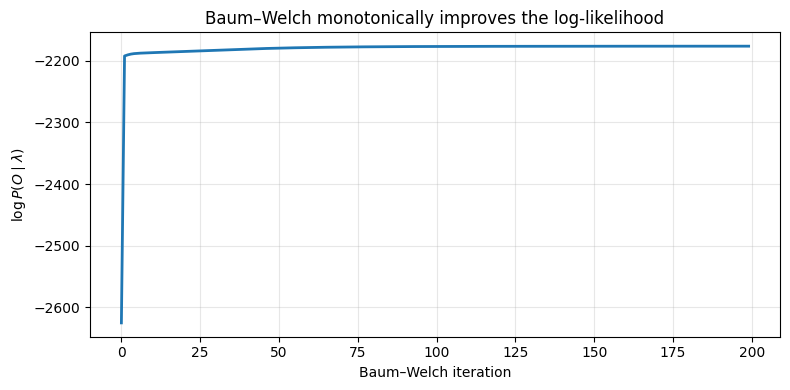

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lls, lw=2)
ax.set_xlabel("Baum–Welch iteration")
ax.set_ylabel(r"$\log P(O \mid \lambda)$")
ax.set_title("Baum–Welch monotonically improves the log-likelihood")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Aligning learned states with the true states

To compare $\hat A$ with $A$ we need to figure out which learned state corresponds to which true state. We try **both** permutations of the two learned states and pick the one that minimises the distance to the true $B$.

In [16]:
from itertools import permutations

def align_to_true(pi_hat, A_hat, B_hat, B_true):
    '''
    Find the best label permutation perm of the learned states such that
    B_hat[perm] is closest to B_true. Apply that permutation everywhere.
    '''
    N = A_hat.shape[0]
    best_perm, best_err = None, np.inf
    for perm in permutations(range(N)):
        perm = np.array(perm)
        err = np.sum((B_hat[perm] - B_true) ** 2)
        if err < best_err:
            best_perm, best_err = perm, err
    p = best_perm
    return pi_hat[p], A_hat[p][:, p], B_hat[p]


pi_aligned, A_aligned, B_aligned = align_to_true(pi_hat, A_hat, B_hat, B)
print("Aligned pi_hat =", pi_aligned, "    (true:", pi, ")")
print("\nAligned A_hat =\n", A_aligned)
print("\nTrue A =\n", A)
print("\nAligned B_hat =\n", B_aligned)
print("\nTrue B =\n", B)

# Quantitative summary
print(f"\nFrobenius distance ||A_hat - A||_F = {np.linalg.norm(A_aligned - A):.4f}")
print(f"Frobenius distance ||B_hat - B||_F = {np.linalg.norm(B_aligned - B):.4f}")


Aligned pi_hat = [0. 1.]     (true: [0.6 0.4] )

Aligned A_hat =
 [[0.7258 0.2742]
 [0.236  0.764 ]]

True A =
 [[0.7 0.3]
 [0.4 0.6]]

Aligned B_hat =
 [[0.0854 0.4258 0.4888]
 [0.5743 0.2404 0.1853]]

True B =
 [[0.1 0.4 0.5]
 [0.7 0.2 0.1]]

Frobenius distance ||A_hat - A||_F = 0.2348
Frobenius distance ||B_hat - B||_F = 0.1603


The recovered parameters should be quite close to the truth — the small residual error is due to (a) the finite training sequence (T = 2000) and (b) random initialisation. If you crank up `T_train` to 20000 and re-run, the gap shrinks further.

## 8. Comparison with the `hmmlearn` library

In production you'd use a battle-tested library rather than rolling your own. The most common choice in Python is [`hmmlearn`](https://hmmlearn.readthedocs.io/). Its `CategoricalHMM` (formerly `MultinomialHMM`) is the discrete-observation HMM we've been studying.

The cell below trains an `hmmlearn` HMM on the same data and confirms our scratch implementation gets a comparable answer.


In [17]:
from hmmlearn import hmm

# hmmlearn expects observations as a 2D column vector of shape (T, 1)
X = O_train.reshape(-1, 1)

# CategoricalHMM with N=2 hidden states and M=3 categories per emission.
model = hmm.CategoricalHMM(
    n_components=2,
    n_iter=200,
    tol=1e-6,
    random_state=1,
    init_params="ste",   # 's' startprob, 't' transmat, 'e' emissionprob — all initialised
)
# Some hmmlearn versions infer n_features from data; setting it explicitly is safer.
model.n_features = 3

model.fit(X)

print("hmmlearn startprob_  =", model.startprob_)
print("\nhmmlearn transmat_   =\n", model.transmat_)
print("\nhmmlearn emissionprob_ =\n", model.emissionprob_)

# Score the same observations and compare to our scratch implementation.
log_p_lib  = model.score(X)
_, c_ours  = forward_scaled(pi_aligned, A_aligned, B_aligned, O_train)
log_p_ours = -np.sum(np.log(c_ours))

print(f"\nlog P(O|lambda) — hmmlearn  : {log_p_lib:.4f}")
print(f"log P(O|lambda) — our scratch: {log_p_ours:.4f}")


hmmlearn startprob_  = [0. 1.]

hmmlearn transmat_   =
 [[0.2662 0.7338]
 [0.3533 0.6467]]

hmmlearn emissionprob_ =
 [[0.2674 0.732  0.0007]
 [0.3875 0.1307 0.4818]]

log P(O|lambda) — hmmlearn  : -2194.7235
log P(O|lambda) — our scratch: -2176.3733


## 9. A larger experiment — discovering vowels vs. consonants

This is the famous experiment from Stamp §8 (originally Cave & Neuwirth 1980). The setup:

- Take a body of English text.
- Reduce it to **27 symbols**: the 26 lowercase letters plus the space character.
- Train a 2-state HMM ($N = 2$, $M = 27$) on this raw stream of characters.

Astonishingly, with **no prior knowledge** of English, the algorithm discovers that one hidden state emits vowels (and spaces) with high probability, and the other emits consonants. The vowel/consonant distinction is statistically detectable purely from the bigram structure of English.

Below we reproduce a small version of this experiment using a chunk of public-domain English text.


In [18]:
import string

# A short chunk of public-domain text (the opening of Pride and Prejudice).
# In practice you'd use ~50,000 characters as Stamp does. We'll use a smaller
# corpus for speed but it still shows the effect clearly.
TEXT = (
    "It is a truth universally acknowledged that a single man in possession of a "
    "good fortune must be in want of a wife. However little known the feelings or "
    "views of such a man may be on his first entering a neighbourhood this truth "
    "is so well fixed in the minds of the surrounding families that he is "
    "considered the rightful property of some one or other of their daughters. "
    "My dear Mr Bennet said his lady to him one day have you heard that "
    "Netherfield Park is let at last Mr Bennet replied that he had not. But it "
    "is returned she for Mrs Long has just been here and she told me all about "
    "it. Mr Bennet made no answer. Do you not want to know who has taken it cried "
    "his wife impatiently. You want to tell me and I have no objection to "
    "hearing it. This was invitation enough."
) * 8     # repeat to lengthen the sequence

# We multiply the corpus by 8 to give Baum-Welch enough data to converge.
# In a real experiment you'd pull text from the Brown Corpus or Project Gutenberg.

# ---- Build the alphabet and convert text to integer indices ----
alphabet = string.ascii_lowercase + " "       # 27 symbols
char2idx = {c: i for i, c in enumerate(alphabet)}

def text_to_obs(text):
    '''Lowercase, keep only a-z and spaces, convert to integer indices.'''
    text = text.lower()
    return np.array([char2idx[c] for c in text if c in char2idx], dtype=int)

O_text = text_to_obs(TEXT)
print(f"Corpus length (after cleaning): T = {len(O_text)} characters")
print(f"Alphabet size:                  M = {len(alphabet)}")


Corpus length (after cleaning): T = 6112 characters
Alphabet size:                  M = 27


In [19]:
# Train a 2-state HMM on the text. With M=27 and ~10000 chars this takes a few seconds.
pi_t, A_t, B_t, lls_t = baum_welch(
    O_text, N=2, M=27, n_iter=80, tol=1e-3, seed=2, verbose=False
)

print(f"Final log P(O|lambda) = {lls_t[-1]:.2f}")
print(f"Iterations run         = {len(lls_t)}")

print("\nLearned transition matrix A:\n", A_t)
print("\nLearned initial distribution pi:", pi_t)


Final log P(O|lambda) = -16383.73
Iterations run         = 80

Learned transition matrix A:
 [[0.2688 0.7312]
 [0.7779 0.2221]]

Learned initial distribution pi: [1. 0.]


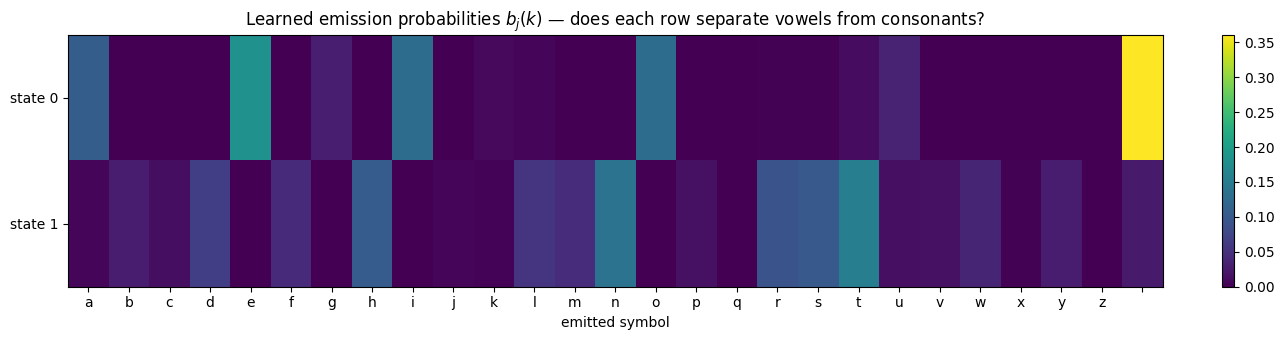

State 0: top-8 emissions  ->  _eoiaugt   (probs: [0.361 0.183 0.127 0.127 0.106 0.035 0.03  0.012])
State 1: top-8 emissions  ->  tnhsrdlm   (probs: [0.155 0.138 0.105 0.1   0.092 0.068 0.056 0.046])


In [20]:
# Visualise the learned emission matrix B_t.
# Each row is a hidden state's distribution over the 27 symbols. If the algorithm
# has rediscovered vowels vs consonants, one row will spike on a, e, i, o, u (and space)
# while the other will spike on consonants.

fig, ax = plt.subplots(figsize=(13, 3.5))
im = ax.imshow(B_t, cmap="viridis", aspect="auto")
ax.set_yticks([0, 1])
ax.set_yticklabels(["state 0", "state 1"])
ax.set_xticks(range(27))
ax.set_xticklabels(list(alphabet))
ax.set_xlabel("emitted symbol")
ax.set_title("Learned emission probabilities $b_j(k)$ — does each row separate vowels from consonants?")
fig.colorbar(im, ax=ax, fraction=0.025)
plt.tight_layout()
plt.show()

# A more readable view: which letters does each state most prefer?
for j in range(2):
    top = np.argsort(B_t[j])[::-1][:8]
    chars = "".join(alphabet[k] if alphabet[k] != " " else "_" for k in top)
    print(f"State {j}: top-8 emissions  ->  {chars}   "
          f"(probs: {B_t[j][top].round(3)})")


You should see one of the rows light up on the vowels `a, e, i, o, u` (and often space `_`) while the other lights up on consonants like `t, n, s, r, h`. Cave & Neuwirth obtained the same result on a much larger corpus in 1980. **The model rediscovered a fundamental linguistic distinction without ever being told what a vowel is.**

(If you don't see a clean separation, the algorithm may have landed in a poor local optimum. Try a different `seed`, increase the corpus length, or run more iterations.)


## 10. Summary

We've covered the core machinery of Hidden Markov Models, end to end:

| Concept | Key formula | Cost |
|---|---|---|
| Markov chain     | $P(q_t \mid q_{t-1})$  | — |
| HMM definition   | $\lambda = (A, B, \pi)$ | — |
| **Forward**      | $\alpha_t(j) = b_j(O_t) \sum_i \alpha_{t-1}(i) a_{ij}$ | $O(N^2 T)$ |
| **Backward**     | $\beta_t(i) = \sum_j a_{ij} b_j(O_{t+1}) \beta_{t+1}(j)$ | $O(N^2 T)$ |
| **Viterbi**      | $v_t(j) = \max_i v_{t-1}(i) a_{ij} b_j(O_t)$           | $O(N^2 T)$ |
| **Baum–Welch**   | EM loop on $\xi_t(i,j)$ and $\gamma_t(i)$              | $O(N^2 T)$ per iteration |

Key takeaways:

1. **The Markov assumption + output independence** is what makes the recursive algorithms work. Both are strong assumptions that don't always hold in real data.
2. **Dynamic programming** (forward, backward, Viterbi) reduces an exponential search to a polynomial one.
3. **Baum–Welch is EM** — guaranteed monotone, but local maxima are real, so initialisation matters.
4. **Numerical scaling** is not optional for non-trivial sequence lengths.
5. The model is surprisingly powerful: with only two hidden states it can rediscover vowel/consonant structure from raw text.

### Where to go next

- **Continuous observations:** replace the categorical $B$ with a Gaussian emission $b_j(\mathbf{o}) = \mathcal{N}(\mathbf{o};\, \mu_j, \Sigma_j)$. `hmmlearn.GaussianHMM` does this.
- **Higher-order HMMs:** let $q_t$ depend on $q_{t-1}$ *and* $q_{t-2}$ (Stamp Exercise 8). You can always re-cast this as a first-order HMM with an enlarged state space.
- **Conditional Random Fields (CRFs):** the discriminative cousin of HMMs — model $P(X \mid O)$ directly instead of the joint $P(X, O)$.
- **Recurrent / Transformer sequence models:** modern neural approaches relax both Markov and output-independence assumptions, at the cost of interpretability.

### References

- M. Stamp, *A Revealing Introduction to Hidden Markov Models* (2021).
- D. Jurafsky & J. H. Martin, *Speech and Language Processing*, Appendix A (2023 draft).
- L. R. Rabiner, *A tutorial on hidden Markov models and selected applications in speech recognition*, Proc. IEEE 77(2), 1989.
- R. L. Cave & L. P. Neuwirth, *Hidden Markov Models for English*, IDA-CRD, 1980.
